# Ejercicio Guiado: Planificando el Viaje Perfecto

## Celda 1: Importaciones y Datos del Problema

In [1]:
import heapq
import networkx as nx
import matplotlib.pyplot as plt

# Grafo con los costos reales de transporte (g)
costo_viajes = {
    'Casa': {'Estacion Autobus': 10, 'Estacion Tren': 40},
    'Estacion Autobus': {'Aeropuerto': 20},
    'Estacion Tren': {'Ciudad Capital': 60},
    'Aeropuerto': {'Hotel de Playa': 150},
    'Ciudad Capital': {'Hotel de Playa': 50},
    'Hotel de Playa': {}
}

# Estimación del costo restante (heurística h)
costo_estimado = {
    'Casa': 100, 
    'Estacion Autobus': 80,
    'Estacion Tren': 90, 
    'Aeropuerto': 120,
    'Ciudad Capital': 40, 
    'Hotel de Playa': 0
}

## Celda 2: Funciones de Búsqueda (Tus Algoritmos)

In [2]:
# --- Implementación de Búsqueda Voraz Primero el Mejor ---
def greedy_best_first(graph, start, goal, heuristics):
    priority_queue = [(heuristics[start], [start])]
    visited = set()
    
    while priority_queue:
        _, path = heapq.heappop(priority_queue)
        node = path[-1]
        
        if node in visited: continue
        visited.add(node)
        
        if node == goal: return path
        
        for neighbor in graph[node]:
            if neighbor not in visited:
                heapq.heappush(priority_queue, (heuristics[neighbor], path + [neighbor]))
    return None

# --- Implementación de Búsqueda A* (A-Estrella) ---
def a_star_search(graph, start, goal, heuristics):
    priority_queue = [(0 + heuristics[start], 0, [start])]
    visited = set()
    
    while priority_queue:
        f, g, path = heapq.heappop(priority_queue)
        node = path[-1]
        
        if node in visited: continue
        visited.add(node)
        
        if node == goal: return path, g
        
        for neighbor, cost in graph[node].items():
            if neighbor not in visited:
                new_g = g + cost
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(priority_queue, (new_f, new_g, path + [neighbor]))
    return None, -1

## Celda 3: Ejecución y Comparación

In [3]:
origen = 'Casa'
destino = 'Hotel de Playa'

# Ejecutar Búsqueda Voraz
ruta_greedy = greedy_best_first(costo_viajes, origen, destino, costo_estimado)
print("🔍 BÚSQUEDA VORAZ (Greedy)")
print(f"Ruta tomada: {ruta_greedy}")
print("-" * 40)

# Ejecutar A*
ruta_a_star, costo_total_a_star = a_star_search(costo_viajes, origen, destino, costo_estimado)
print("⭐ BÚSQUEDA A* (Óptima)")
print(f"Ruta tomada: {ruta_a_star}")
print(f"Costo Total: ${costo_total_a_star}")

🔍 BÚSQUEDA VORAZ (Greedy)
Ruta tomada: ['Casa', 'Estacion Tren', 'Ciudad Capital', 'Hotel de Playa']
----------------------------------------
⭐ BÚSQUEDA A* (Óptima)
Ruta tomada: ['Casa', 'Estacion Tren', 'Ciudad Capital', 'Hotel de Playa']
Costo Total: $150


## Celda 4: Visualización del Grafo y la Ruta Óptima

/tmp/ipykernel_35749/3786876201.py:46: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


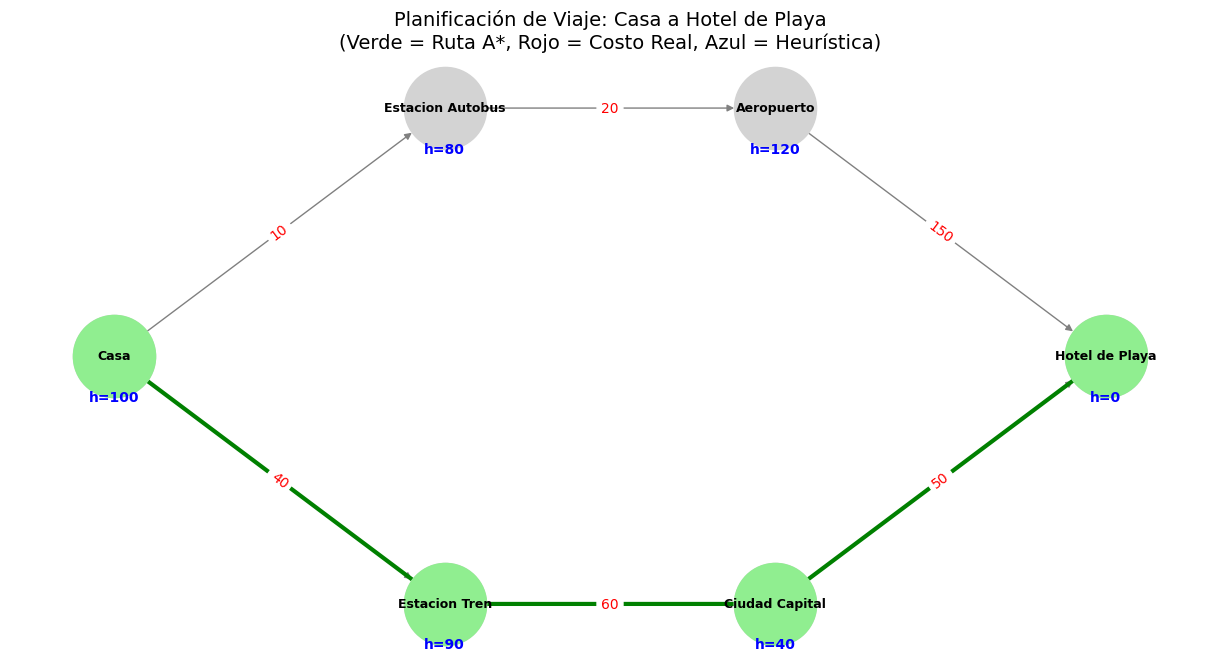

In [4]:
# Crear el grafo dirigido
G = nx.DiGraph()

# Poblar el grafo con los datos
for nodo_origen, destinos in costo_viajes.items():
    for nodo_destino, costo in destinos.items():
        G.add_edge(nodo_origen, nodo_destino, weight=costo)

# Configurar el lienzo
plt.figure(figsize=(12, 6))

# Crear un layout personalizado para que se vea como un mapa lógico
posiciones = {
    'Casa': (0, 1),
    'Estacion Autobus': (1, 2),
    'Estacion Tren': (1, 0),
    'Aeropuerto': (2, 2),
    'Ciudad Capital': (2, 0),
    'Hotel de Playa': (3, 1)
}

# 1. Dibujar el grafo base (nodos grises y aristas)
nx.draw(G, posiciones, with_labels=True, node_color='lightgray', node_size=3500, 
        font_size=9, font_weight='bold', edge_color='gray', arrows=True)

# 2. Resaltar la ruta óptima de A* (en verde)
if ruta_a_star:
    # Crear una lista de tuplas con las conexiones de la ruta ganadora
    aristas_a_star = [(ruta_a_star[i], ruta_a_star[i+1]) for i in range(len(ruta_a_star)-1)]
    # Pintar nodos y bordes de la ruta
    nx.draw_networkx_nodes(G, posiciones, nodelist=ruta_a_star, node_color='lightgreen', node_size=3500)
    nx.draw_networkx_edges(G, posiciones, edgelist=aristas_a_star, edge_color='green', width=3, arrows=True)

# 3. Dibujar las etiquetas de los costos de viaje (en rojo)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, posiciones, edge_labels=edge_labels, font_color='red')

# 4. Añadir las heurísticas debajo de cada nodo (en azul)
for nodo, (x, y) in posiciones.items():
    h_val = costo_estimado[nodo]
    plt.text(x, y - 0.18, s=f"h={h_val}", color='blue', fontweight='bold', 
             horizontalalignment='center')

plt.title("Planificación de Viaje: Casa a Hotel de Playa\n(Verde = Ruta A*, Rojo = Costo Real, Azul = Heurística)", fontsize=14)
plt.axis('off') # Ocultar los ejes para que parezca un mapa limpio
plt.tight_layout()
plt.show()